In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def plot_3D(x, y, arr):
    # Assume arr is your n x n array
    X, Y = np.meshgrid(x, y)
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the surface
    ax.plot_surface(X, Y, arr, cmap='viridis')  # you can change the colormap
    ax.set_xlabel(r'$\rho$ axis')
    ax.set_ylabel(r'$\tau$ axis')
    ax.set_zlabel('Z axis (array values)')
    ax.view_init(elev=30, azim=135)
    
    plt.show()

def plot_contour2D(x, y, arr):
    X, Y = np.meshgrid(x, y)
    
    plt.figure()
    cf = plt.contourf(X, Y, arr, levels=20, cmap='viridis')
    plt.xlabel(r'$\rho$ axis')
    plt.ylabel(r'$\tau$ axis')
    plt.title('ESJD 2D Filled Contour Plot')
    plt.colorbar(cf)  # Show color scale
    plt.show()


    

In [3]:
PKL_titles

['config_dim6_exp_gaussian.py_04042425125127.pkl']

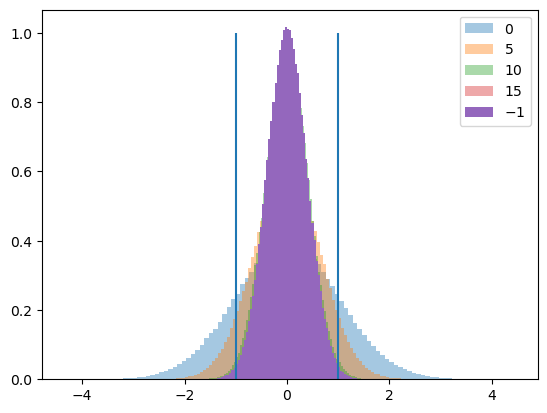

In [5]:
idx=0
for t in np.concatenate([np.arange(0, PKLs[idx]['res'][0].shape[1], 5), [-1]]):
    if t == -1:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=1, density=True, label=rf"${-1}$")
    else:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=0.4, density=True, label=rf"${t}$")
plt.legend()
plt.vlines(x=1, ymin=0, ymax=1)
plt.vlines(x=-1, ymin=0, ymax=1)

0.0409375


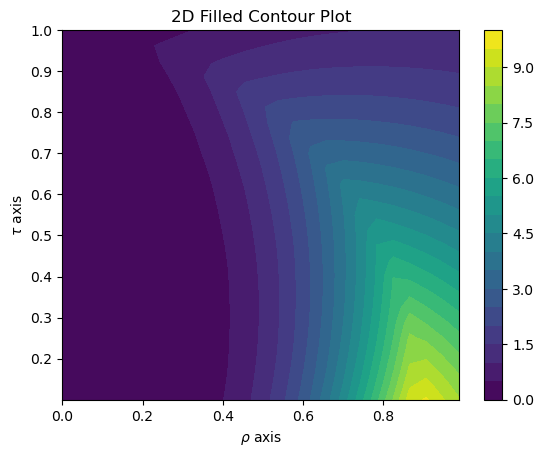

0.34344947


<Figure size 640x480 with 0 Axes>

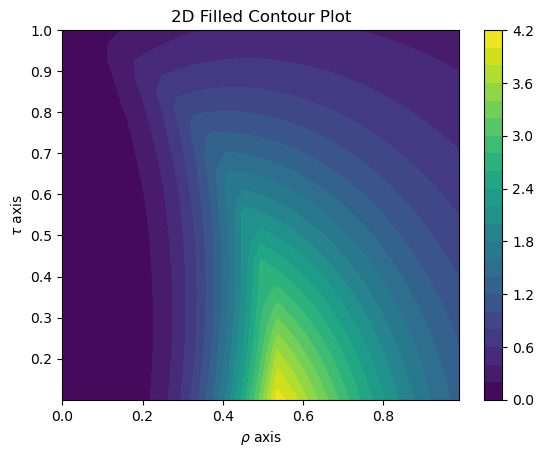

1.0


<Figure size 640x480 with 0 Axes>

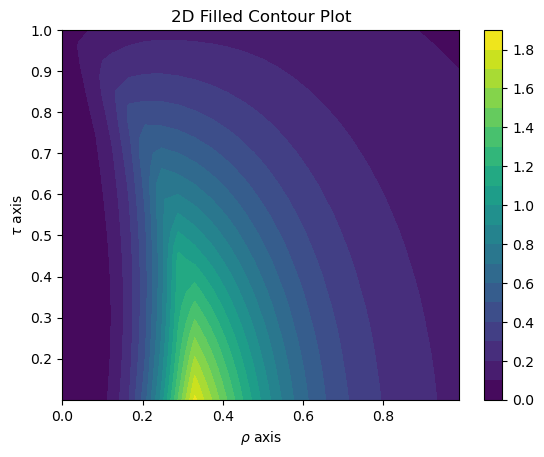

1.0


<Figure size 640x480 with 0 Axes>

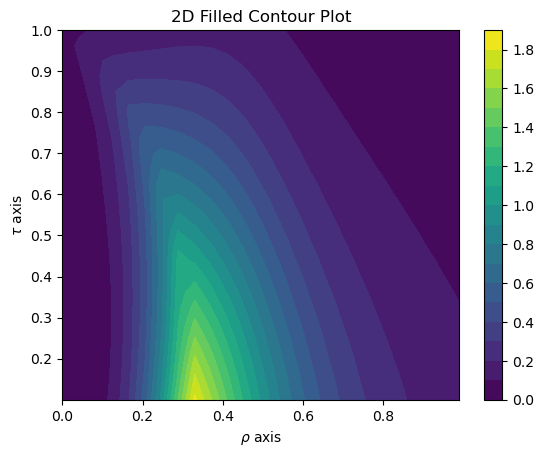

<Figure size 640x480 with 0 Axes>

In [57]:
rho_grid = jnp.linspace(0, 0.99, 25)
tau_grid = jnp.linspace(0.1, 1, 25)


idx = 0
t = PKLs[idx]['res'][5].shape[1]
vals = PKLs[idx]['res'][5].mean(axis=0).reshape((t, 25, 25))
for t in np.arange(0, vals.shape[0], 5):
    print(PKLs[idx]['res'][6][:,t].mean())
    arr = vals[t]
    plot_contour2D(rho_grid, tau_grid, arr)
    plt.clf()

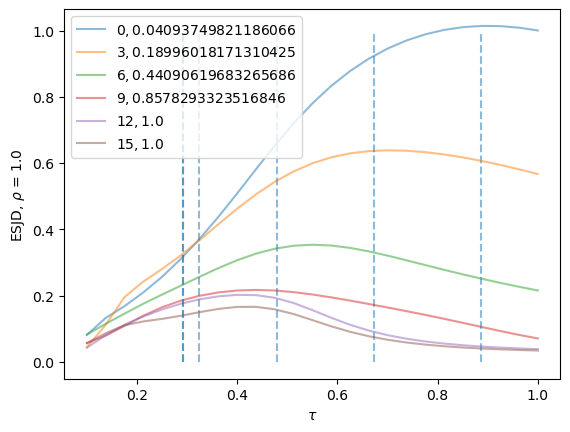

<Figure size 640x480 with 0 Axes>

In [25]:
def slice_esjd(idx=0, slic=-1, axis=0):
    grid = tau_grid if axis==0 else rho_grid
    t = PKLs[idx]['res'][5].shape[1]
    vals = PKLs[idx]['res'][5].mean(axis=0)
    vals = vals.reshape((t, rho_grid.shape[0], tau_grid.shape[0]))
    dim = PKLs[idx]['res'][0].shape[-1]
    for t in np.arange(0, vals.shape[0], 3):
        my_slice = vals[t, slic, :] if axis==0 else vals[t,:, slic]
        lmbd = PKLs[idx]['res'][6].mean(axis=0)[t]
        plt.plot(grid, my_slice, label=rf"${t}, {lmbd}$", alpha=0.5)
        sigmasq = (0.3**(-1)-1)**(-1)
        if axis==0:
            plt.vlines(x=2.38/np.sqrt(dim) * (lmbd*sigmasq**(-1)+1)**(-1), ymin=0, ymax=1,  linestyle="--", alpha=0.5)
    plt.legend()
    xlabel = r"$\tau$" if axis==0 else r"$\rho$"
    oppositexlabel = r"$\rho$" if axis==0 else r"$\tau$"
    plt.xlabel(xlabel)
    plt.ylabel(r"ESJD, "+oppositexlabel+" = "+str(grid[slic]))
    plt.show()
    plt.clf()

slice_esjd(0, -1)

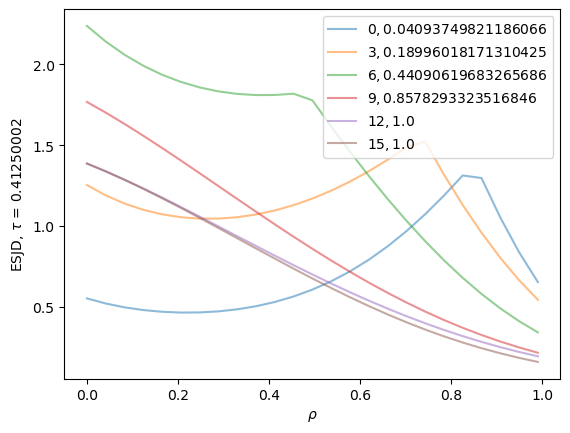

<Figure size 640x480 with 0 Axes>

In [28]:
slice_esjd(0, 10, 1)

(25, 16)


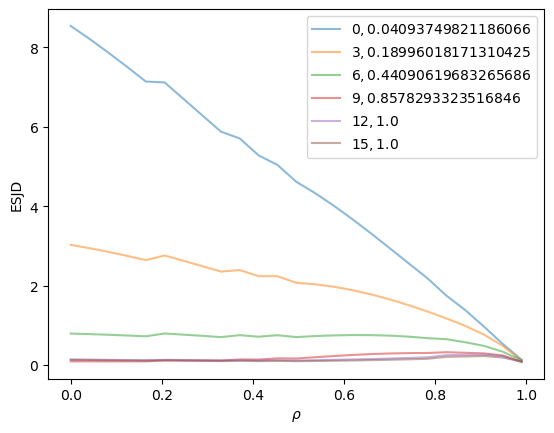

<Figure size 640x480 with 0 Axes>

In [54]:
def esjd_ar(idx, rho):
    tau = np.sqrt(1-rho**2)
    idx_tau  = np.argmin(np.abs(tau_grid - tau))
    idx_rho = np.argmin(np.abs(rho_grid - rho))
    t = PKLs[idx]['res'][5].shape[1]
    vals = PKLs[idx]['res'][5].mean(axis=0)
    vals = vals.reshape((t, rho_grid.shape[0], tau_grid.shape[0]))
    dim = PKLs[idx]['res'][0].shape[-1]
    return vals[:, idx_rho, idx_tau]
def plot_esjd_ar(idx):
    grid = rho_grid
    esjd_along_the_circle = np.array([esjd_ar(idx, rho) for rho in rho_grid])
    print(esjd_along_the_circle.shape)
    for t in np.arange(0, vals.shape[0], 3):
        my_slice = esjd_along_the_circle[:,t]
        lmbd = PKLs[idx]['res'][6].mean(axis=0)[t]
        plt.plot(grid, my_slice, label=rf"${t}, {lmbd}$", alpha=0.5)
        sigmasq = (0.3**(-1)-1)**(-1)
    plt.legend()
    xlabel = r"$\rho$"
    oppositexlabel = r"$\tau=\sqrt(1-\rho^2)$" 
    plt.xlabel(xlabel)
    plt.ylabel(r"ESJD")
    plt.show()
    plt.clf()
plot_esjd_ar(0)

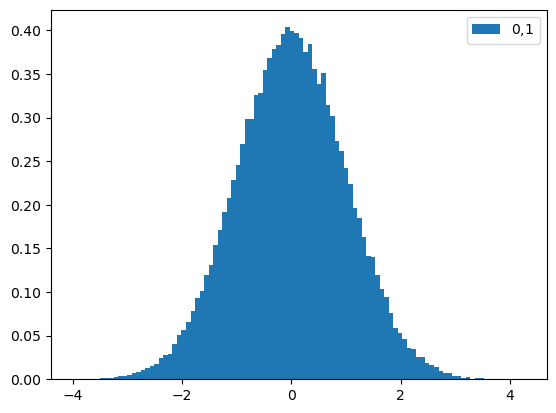

<Figure size 640x480 with 0 Axes>

In [8]:
def get_hist(idx, dim, t):
    if dim == -1:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=1, density=True, label=rf"${t}$")
    else:
        plt.hist(PKLs[idx]['res'][0][:,t,0,..., dim].reshape(-1), bins=100, alpha=1, density=True, label=rf"${t}$,${dim+1}$")
    plt.legend()
    plt.show()
    plt.clf()
get_hist(2, 0, 0)

In [61]:
PKLs[idx]['res'][6]

Array([[0.05350586, 0.10740402, 0.20531887, 0.3440556 , 0.530681  ,
        0.7685463 , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        ]], dtype=float32)